<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #44a305 solid;
                   background-color:#F4F9E6;
                   color:#6ba340;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #44a305 solid;
                   background-color:#F4F9E6;
                   color:#6ba340;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Métodos Numéricos
        </td>
        <td style="border: 1px #44a305 solid;
                   background-color:#F4F9E6;
                   color:#6ba340;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 22 - Método de Ostrowski
        </td>
    </tr>
    <tr>
 

</table>

In [34]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Método de Ostrowski

In [35]:
def Ostrowski(f,df,x0,tol,maxiter):
    iters = 0
    error = tol+1
    error_x = list()

    while error>tol and iters<=maxiter:
        y = x0-f(x0)/df(x0)
        x = y-f(x0)/(f(x0)-2*f(y))*f(y)/df(x0)
        error = math.fabs(x-x0)
        error_x.append(error)
        iters = iters+1
        x0 = x
        
    
    
    error_x = np.array(error_x)
    eps = 1e-16
    error_x_safe = np.maximum(error_x, eps)
    ACOC = np.log(error_x_safe[2:]/error_x_safe[1:-1])/np.log(error_x_safe[1:-1]/error_x_safe[0:-2])
    return [x,iters,error,ACOC]

## Método de Ostrowski con Tabla

In [36]:
def Ostrowskitabla(f,df,x0,tol,maxiter):
    iters = 0
    error = tol+1
    lista_x = list(); lista_e = list() #Se crean listas para x y el error

    while error>tol and iters<=maxiter:
        y = x0-f(x0)/df(x0)
        x = y-f(x0)/(f(x0)-2*f(y))*f(y)/df(x0)
        error = math.fabs(x-x0)
        iters = iters+1
        x0 = x
        lista_x.append(x); lista_e.append(error);
    tabla = pd.DataFrame({'Iteraciones': lista_x, 'Error': lista_e}) #Se crear el dataframe
    pd.set_option('display.precision', 12)
    return tabla

## Ejemplo 1
Resolver la ecuación no lineal
$$2+(x-1)^3+e^{x^2}=0$$
Usando el método de Ostrowski con $x_0=-1$ y una tolerancia de $10^{-10}$

In [37]:
##Introducir f
f = lambda x: 2+(x-1)**3+math.exp(x**2)

#Introducir df
df = lambda x: 3*(x-1)**2+2*x*math.exp(x**2)

x0 = -1
tol = 1e-10
maxiter = 30

x,iters,error,ACOC = Ostrowski(f,df,x0,tol,maxiter)

In [38]:
print("La solución a la ecuación es x = %s" %x)
print("Las iteraciones realizadas fueron %s" %iters)
print("El error que se tuvo fue de %s" %error)
print("El vector del ACOC es %s" %ACOC)

La solución a la ecuación es x = -0.48322324875500755
Las iteraciones realizadas fueron 3
El error que se tuvo fue de 2.911781926684398e-12
El vector del ACOC es [3.70831891]


In [39]:
Ostrowskitabla(f,df,x0,tol,maxiter)

,Iteraciones,Error
0,-0.485325586654,0.514674413346
1,-0.483223248758,0.002102337896
2,-0.483223248755,0.000000000003


## Ejemplo 2

Se considera la ecuación
$$\ln (x^2+2)-x^3+1=0$$

- Realizar una representación gráfica para averiguar el número de soluciones y obtener una estimación inicial de las mismas.
- Resolver aplicando el método de Ostrowski con una tolerancia de $10^{-10}$.


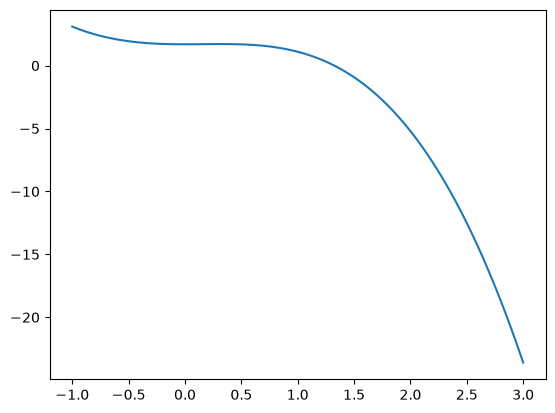

In [40]:
#Graficar la función
x = np.linspace(-1,3,100)
y = np.log(x**2+2)-x**3+1

plt.figure()
plt.plot(x,y)
plt.show()

In [41]:
#La estimación inicial es x0=1

In [42]:
f = lambda x: math.log(x**2+2)-x**3+1
df = lambda x: 2*x/(x**2+2)-3*x**2
x0 = 1
tol = 1e-8
maxiter = 30

x,iters,error,ACOC = Ostrowski(f,df,x0,tol,maxiter)

print("El valor de la aproximación es %s" %x)
print("El número de iteraciones realizadas es de %s" %iters)
print("El error cometido fue %s" %error)
print("Los resultados del ACOC son %s" %ACOC)

El valor de la aproximación es 1.3243532357830654
El número de iteraciones realizadas es de 3
El error cometido fue 4.701639300108695e-09
Los resultados del ACOC son [4.17471897]


In [43]:
Ostrowskitabla(f,df,x0,tol,maxiter)

,Iteraciones,Error
0,1.334515898607,0.334515898607
1,1.324353240485,0.010162658123
2,1.324353235783,0.000000004702


## Ejemplo 3

En ingeniería oceanográfica, la ecuación de una ola reflejada en un puerto está dada por $\lambda =16$, $t=12$ y $v=48$
$$h=\sin \left(\dfrac{2\pi x}{\lambda}  \right)\cos \left(\dfrac{2\pi tv}{\lambda} \right)+e^{-x}$$
Resolver para el valor positivo más bajo de $x$ si $h=0.5$.

Reemplazamos los datos en la ecuación
$$0.5=\sin \left(\dfrac{2\pi x}{16}  \right)\cos \left(\dfrac{2\pi (48)}{16} \right)+e^{-x}$$

Al simplificar se obtiene

$$\sin \left(\dfrac{\pi x}{8}  \right)\cos \left(72 \pi \right)+e^{-x}-0.5=0.$$

De este modo $$f(x)=\sin \left(\dfrac{\pi x}{8}  \right)\cos \left(72 \pi \right)+e^{-x}-0.5$$

In [44]:
f = lambda x: math.sin(math.pi/8*x)*math.cos(72*math.pi)+math.exp(-x)-0.5
df = lambda x: math.pi/8*math.cos(math.pi/8*x)*math.cos(72*math.pi)-math.exp(-x)
x0 = 6
tol = 1e-10
maxiter = 30

x,iters,error,ACOC = Ostrowski(f,df,x0,tol,maxiter)

print("El valor de la aproximación es %s" %x)
print("El número de iteraciones realizadas es de %s" %iters)
print("El error cometido fue %s" %error)
print("Los resultados del ACOC son %s" %ACOC)

El valor de la aproximación es 6.670393253321528
El número de iteraciones realizadas es de 3
El error cometido fue 2.6645352591003757e-14
Los resultados del ACOC son [4.10381964]


In [45]:
Ostrowskitabla(f,df,x0,tol,maxiter)

,Iteraciones,Error
0,6.671983753621,6.719837536211e-01
1,6.670393253322,1.590500299504e-03
2,6.670393253322,2.664535259100e-14


## Comparativa con los Método de Newton y Traub

In [46]:
def Newton(f,df,x0,tol,maxiter):
    iters = 0
    error = tol+1
    error_x = list()

    while error>tol and iters<=maxiter:
        x = x0-f(x0)/df(x0)
        error = math.fabs(x-x0)
        error_x.append(error)
        iters = iters+1
        x0 = x

    error_x = np.array(error_x)
    ACOC = np.log(error_x[2:]/error_x[1:-1])/np.log(error_x[1:-1]/error_x[0:-2])
    return [x, iters, error, ACOC]

In [47]:
def TraubACOC(f,df,x0,tol,maxiter):
    iters = 0
    error = tol+1
    error_x = list()

    while error>tol and iters<=maxiter:
       
        y = x0-f(x0)/df(x0)
        x = y-f(y)/df(x0)
        error = math.fabs(x-x0)
        error_x.append(error)
        iters = iters+1
        x0 = x

    error_x = np.array(error_x)
    ACOC = np.log(error_x[2:]/error_x[1:-1])/np.log(error_x[1:-1]/error_x[0:-2])
    
    return [x,iters,error,ACOC]

In [48]:
## Se utiliza el método de Newton
xn,itersn,errorn,ACOCn = Newton(f,df,x0,tol,maxiter)

## Se utiliza el método de Traub
xt,iterst,errort,ACOCt = TraubACOC(f,df,x0,tol,maxiter)

#Se crea una tabla con los resultados finales
lista_x = [x,xn,xt]
lista_iter = [iters,itersn,iterst]
lista_errore = [error, errorn,errort]
lista_ACOC = [ACOC[0], ACOCn[0], ACOCn[0]]

tabla_final = pd.DataFrame()
tabla_final["Método"] = ["Ostrowski", "Newton", "Traub"]
tabla_final["Soluciones"] = lista_x
tabla_final["Iteraciones"] = lista_iter
tabla_final["Errores"] = lista_errore
tabla_final["ACOC"] = lista_ACOC

/var/folders/qt/89mhcy710gj3n350ps35v5600000gn/T/ipykernel_46080/1565670337.py:16: RuntimeWarning: divide by zero encountered in log
  ACOC = np.log(error_x[2:]/error_x[1:-1])/np.log(error_x[1:-1]/error_x[0:-2])


In [49]:
tabla_final

,Método,Soluciones,Iteraciones,Errores,ACOC
0,Ostrowski,6.670393253322,3,2.664535259100e-14,4.103819641180
1,Newton,6.670393253322,5,8.881784197001e-16,2.111988746344
2,Traub,6.670393253322,4,0.000000000000e+00,2.111988746344
